*Built with Grok Build*

# Homework Module 10


In [2]:
##########################################################################################
# EEE591_419 Python for Rapid Engineering Solutions - HW_M10: HW_M10.py
# Mark Khusid
##########################################################################################

##########################################################################################
# MW_M10
#                    
##########################################################################################


## Import Libraries


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint


## Create Debug Flag


In [4]:
debug = False


## Create Shared Time Vector


In [5]:
T_START = 0.0
T_END = 7.0
NUM_POINTS = 700

t = np.linspace(T_START, T_END, NUM_POINTS)


In [6]:
if debug:
    print(t[:10])
    print(t[-10:])


## Problem 1


### Define Problem 1's Equation Function


In [7]:
def p1_f_prime_y_t(y, t):
    # Return dy/dt for Problem 1
    return np.cos(t)


In [8]:
if debug:
    print(p1_f_prime_y_t(0, t)[:10])


### Define Problem 1's Initial Condition


In [9]:
p1_y_init = 1


### Solve ODE using *odeint*


In [10]:
p1_y_t = odeint(p1_f_prime_y_t, p1_y_init, t)


In [11]:
if debug:
    print(p1_y_t[:10])


### Plot Results


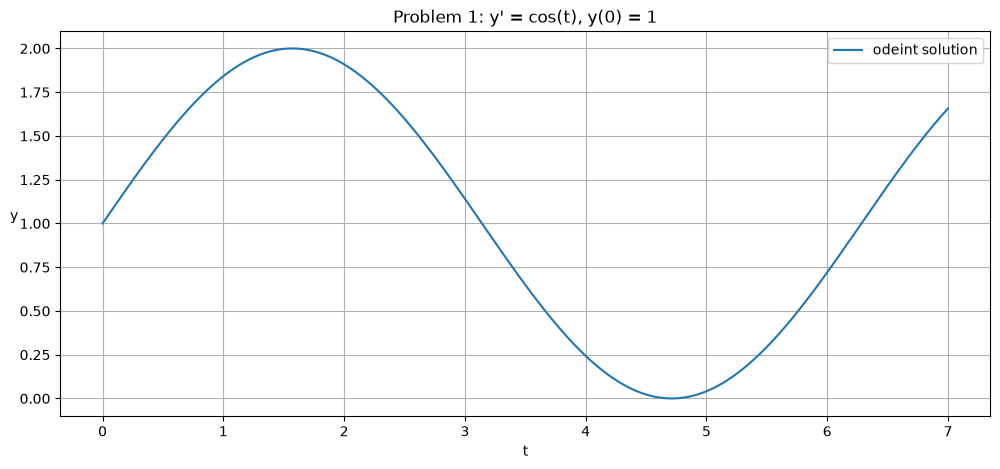

In [12]:
plt.figure(figsize=(12, 5))
plt.plot(t, p1_y_t, label='odeint solution')
if debug:
    plt.plot(t, p1_f_prime_y_t(0, t), label='y\'(t)')
plt.xlabel('t')
plt.ylabel('y', rotation=0)
plt.title("Problem 1: y' = cos(t), y(0) = 1")
plt.grid()
plt.legend()
plt.show()


## Problem 2


### Define Problem 2's Equation Function


In [13]:
# y' = -y + t**2 * e**(-2*t) + 10, y(0) = 0
def p2_f_prime_y_t(y, t):
    # Return dy/dt for Problem 2
    return -y + (t**2) * np.exp(-2*t) + 10


In [14]:
if debug:
    print(p2_f_prime_y_t(0, t)[:10])


In [15]:
if debug:
    plt.plot(t, p2_f_prime_y_t(0, t), label='P2 y\'(t)')
    plt.title('Problem 2')
    plt.legend()


### Define Problem 2's Initial Condition


In [16]:
p2_y_init = 0


### Solve ODE using *odeint*


In [17]:
p2_y_t = odeint(p2_f_prime_y_t, p2_y_init, t)


In [18]:
if debug:
    print(p2_y_t[:10])


### Plot Results


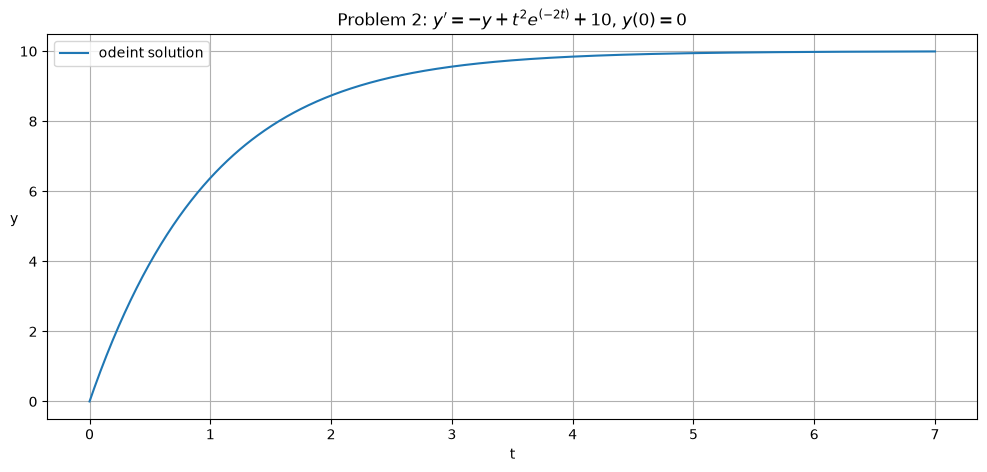

In [19]:
plt.figure(figsize=(12, 5))
plt.plot(t, p2_y_t, label='odeint solution')
if debug:
    p2_f_prime_y_t_debug = -p2_y_t[:,0] + (t**2) * np.exp(-2*t) + 10
    plt.plot(t, p2_f_prime_y_t_debug, label = 'Extracted y\'(t)')
plt.xlabel('t')
plt.ylabel('y', rotation=0)
plt.title(f"Problem 2: $y' = -y + t^2 e^{{(-2t)}} + 10$, $y(0) = 0$")
plt.grid()
plt.legend()
plt.show()


## Problem 3


### Define Problem 3's Equation Function


In [20]:
# -----------------------------------------------------------------------------
# Problem 3
# y'' + 4y' + 4y = 25cos(t) + 25sin(t)
# y(0) = 1, y'(0) = 1
#
# Convert the second-order ODE into two first-order ODEs.
# Let v = y'. Then:
#       y' = v
#       v' = y'' = 25cos(t) + 25sin(t) - 4v - 4y
# -----------------------------------------------------------------------------
def p3_f_derivatives_y_t(r, t):
    """Return [dy/dt, dv/dt] for Problem 3, where v = y'."""
    y = r[0]
    v = r[1]

    dydt = v
    dvdt = 25*np.cos(t) + 25*np.sin(t) - 4*v - 4*y

    return np.array([dydt, dvdt], float)


### Define Problem 3's Initial Conditions


In [21]:
p3_y_init = np.array([1, 1], dtype=float) # [y(0), y'(0)]


In [22]:
if debug:
    print(p3_y_init)


### Solve ODE using *odeint*


In [23]:
p3_f_solutions_y_t = odeint(p3_f_derivatives_y_t, p3_y_init, t)


In [24]:
if debug:
    print(p3_f_solutions_y_t.shape)
    print(p3_f_solutions_y_t[:, 0][:10])
    print(p3_f_solutions_y_t[:, 1][:10])


In [25]:
p3_y_t = p3_f_solutions_y_t[:, 0]
p3_y_prime_t = p3_f_solutions_y_t[:, 1]


### Plot Results


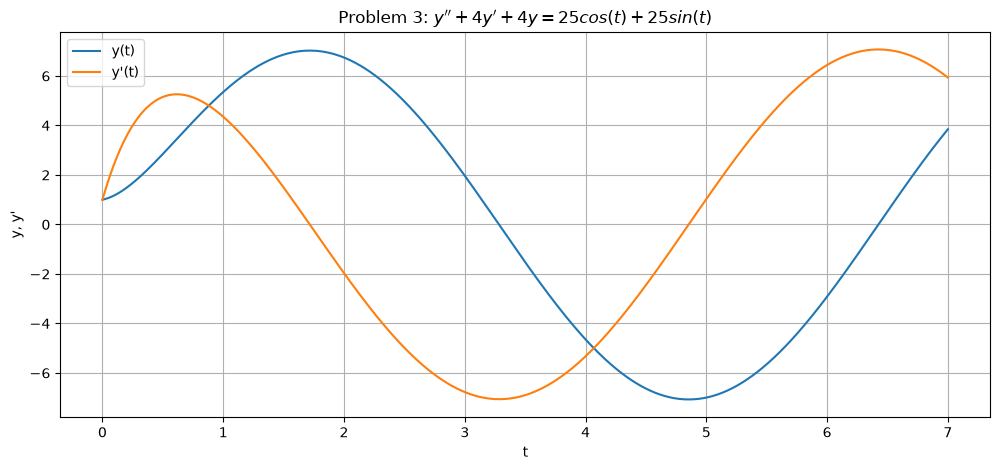

In [26]:
plt.figure(figsize=(12, 5))
plt.plot(t, p3_y_t, label='y(t)')
plt.plot(t, p3_y_prime_t, label='y\'(t)')
plt.xlabel('t')
plt.ylabel('y, y\'')
plt.title(f"Problem 3: $y'' + 4y' + 4y = 25cos(t) + 25sin(t)$")
plt.grid()
plt.legend()
plt.show()
